# Phishing Email Detection Notebook
### I use natural language processing here to decide whether an email looks safe or suspicious.

In this notebook, I load the email dataset, clean the text, turn the words into numeric features, train simple models, compare the results, and save the artefacts that the app needs later.


## 1. Environment Setup and Imports

In this first section, I load the libraries I need for text cleaning, feature building, model training, and evaluation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import warnings
import json
import pickle
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import spacy
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from scipy.sparse import hstack, csr_matrix

# Sklearn Models & Utilities
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# Output Directories
os.makedirs('/content/drive/MyDrive/Colab Notebooks/Osas/saved_models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/Osas/plots', exist_ok=True)



## 2. NLP Module: Phishing Email Detection

Here, I use the **Enron Spam Dataset** to train two beginner-friendly classifiers:
- **Multinomial Naive Bayes**
- **Random Forest**

I compare both models so I can see which one gives better results for this project.


### 2.1 Load & Explore Dataset

In [ ]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Osas/enron_spam_data.csv'

df = pd.read_csv(DATA_PATH)

# Drop unnamed index columns if present
unnamed_cols = [col for col in df.columns if col.startswith('Unnamed')]
df.drop(columns=unnamed_cols, inplace=True)

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head()

Dataset shape : (56611, 5)
Columns       : ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']


,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,12/10/1999
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,12/13/1999
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,12/14/1999
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,12/14/1999
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,12/14/1999


Class distribution:
Spam/Ham
spam                                                                                                 17171
ham                                                                                                  16468
 "" he said .                                                                                           15
2001                                                                                                     9
 he said .                                                                                               9
                                                                                                     ...  
 the company reported that it overstated earnings by $ 586 million over 41 / 2 years                     1
 who is now director of the center for quality financial reporting at colorado state university .        1
 when the number is $ 1 billion . ""                                                                     1
 to clos

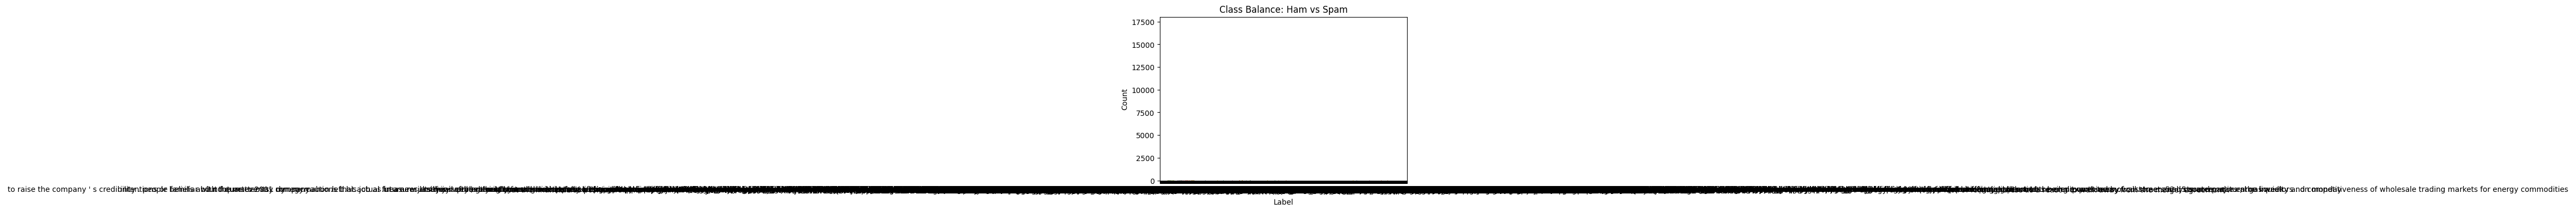

In [ ]:
# Class Distribution
print('Class distribution:')
print(df['Spam/Ham'].value_counts())
print(f'\nMissing values:\n{df.isnull().sum()}')

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Spam/Ham', data=df, hue='Spam/Ham',
              palette='Set2', legend=False, ax=ax)
ax.set_title('Class Balance: Ham vs Spam')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plots/class_balance.png', dpi=150)
plt.show()

### 2.2 Text Preprocessing

In [ ]:
# Load spaCy NLP model
nlp = spacy.load('en_core_web_sm')

# Parts-of-speech to retain (meaningful for spam detection)
KEEP_POS = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}

# Common email boilerplate words to remove
email_noise = {
    'enron', 'ect', 'hou', 'forwarded', 'original', 'attached',
    'fw', 're', 'fwd', 'cc', 'bcc',
    'please', 'thank', 'thanks', 'regards',
    'sincerely', 'dear', 'hello', 'hi', 'hey',
    'said', 'say', 'says'
}

def pre_clean(text):
    """Basic text cleaning: lowercase, remove URLs, emails, numbers, punctuation."""
    if pd.isnull(text) or str(text).strip() == '':
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\S+@\S+', '', text)               # remove email addresses
    text = re.sub(r'\d+', '', text)                   # remove digits
    text = text.translate(
        str.maketrans('', '', string.punctuation))     # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # normalise whitespace
    return text


def pos_filter(doc):
    """Lemmatise and filter tokens by POS tag, removing noise words."""
    tokens = [
        token.lemma_
        for token in doc
        if token.pos_ in KEEP_POS
        and token.lemma_ not in email_noise
        and len(token.lemma_) > 2
        and not token.is_stop
    ]
    return ' '.join(tokens)


# Apply Preprocessing
# Combine subject and message into one text field
df['combined_text'] = df['Subject'].fillna('') + ' ' + df['Message'].fillna('')

# Basic cleaning
df['pre_cleaned'] = df['combined_text'].apply(pre_clean)

# NLP filtering (batch processing for speed)
print('Running NLP preprocessing — this may take a minute...')
df['cleaned_text'] = [
    pos_filter(doc)
    for doc in nlp.pipe(df['pre_cleaned'], batch_size=500,
                        disable=['parser', 'ner'])
]

# Encode labels
df['label'] = df['Spam/Ham'].map({'spam': 1, 'ham': 0})
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

print(f' Preprocessing complete. Dataset size: {df.shape[0]} rows')
print('\nSample cleaned text:')
print(df['cleaned_text'].iloc[0])

Running NLP preprocessing — this may take a minute...
 Preprocessing complete. Dataset size: 33639 rows

Sample cleaned text:
christmas tree farm picture


### 2.3 Feature Engineering

In [ ]:
# Phishing Keywords
phishing_keywords = [
    'verify', 'account', 'password', 'login', 'update', 'confirm',
    'suspend', 'urgent', 'immediately', 'click', 'bank', 'credit',
    'winner', 'prize', 'congratulations', 'free', 'offer', 'limited',
    'expire', 'security', 'unusual', 'activity', 'risk', 'unauthorized'
]

# Statistical Features
df['char_count']            = df['combined_text'].fillna('').apply(len)
df['word_count']            = df['combined_text'].fillna('').apply(lambda x: len(x.split()))
df['unique_word_ratio']     = df['cleaned_text'].fillna('').apply(
    lambda x: len(set(x.split())) / (len(x.split()) + 1))
df['url_count']             = df['combined_text'].fillna('').apply(
    lambda x: len(re.findall(r'http\S+|www\S+', x)))
df['email_count']           = df['combined_text'].fillna('').apply(
    lambda x: len(re.findall(r'\S+@\S+', x)))
df['has_unsubscribe']       = df['combined_text'].fillna('').apply(
    lambda x: int('unsubscribe' in x.lower()))
df['phishing_keyword_count']= df['combined_text'].fillna('').apply(
    lambda x: sum(1 for kw in phishing_keywords if kw in x.lower()))

stat_feature_cols = [
    'char_count', 'word_count', 'unique_word_ratio',
    'url_count', 'email_count', 'has_unsubscribe', 'phishing_keyword_count'
]

print(f'Feature engineering complete. Shape: {df.shape}')
df[['Subject', 'Spam/Ham'] + stat_feature_cols].head(10)

Feature engineering complete. Shape: (33639, 16)


,Subject,Spam/Ham,char_count,word_count,unique_word_ratio,url_count,email_count,has_unsubscribe,phishing_keyword_count
0,christmas tree farm pictures,ham,29,4,0.800000,0,0,0,0
1,"vastar resources , inc .",ham,4307,1577,0.496503,0,0,0,0
2,calpine daily gas nomination,ham,67,12,0.500000,0,0,0,0
3,re : issue,ham,1182,347,0.508475,0,0,0,2
4,meter 7268 nov allocation,ham,1150,322,0.507937,0,0,0,0
5,mcmullen gas for 11 / 99,ham,559,125,0.695652,0,0,0,0
6,meter 1517 - jan 1999,ham,433,95,0.653846,0,0,0,0
7,duns number changes,ham,1395,343,0.797619,0,0,0,0
8,king ranch,ham,1627,330,0.483607,0,0,0,1
9,re : entex transistion,ham,3062,644,0.693023,0,0,0,3


### 2.4 Train/Test Split & TF-IDF Vectorisation

In [ ]:
# Train / Test Split
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

# TF-IDF Vectorisation
cleaned_stop_words = set()
for word in SPACY_STOP_WORDS | email_noise:
    word = word.strip("'")
    if word:
        cleaned_stop_words.add(word)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words=list(cleaned_stop_words),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTF-IDF matrix shape (train): {X_train_tfidf.shape}')

# Combine TF-IDF + Statistical Features
stat_train = df.loc[X_train.index, stat_feature_cols].reset_index(drop=True)
stat_test  = df.loc[X_test.index,  stat_feature_cols].reset_index(drop=True)

stat_train_sparse = csr_matrix(stat_train.values)
stat_test_sparse  = csr_matrix(stat_test.values)

X_train_combined = hstack([X_train_tfidf, stat_train_sparse])
X_test_combined  = hstack([X_test_tfidf,  stat_test_sparse])

# Chi-Squared Feature Selection
tfidf_feature_names = list(tfidf.get_feature_names_out())
all_feature_names   = np.array(tfidf_feature_names + stat_feature_cols)

print('\nRunning Chi-Squared feature selection...')
chi2_selector    = SelectKBest(chi2, k=5000)
X_train_final    = chi2_selector.fit_transform(X_train_combined, y_train)
X_test_final     = chi2_selector.transform(X_test_combined)

selected_mask  = chi2_selector.get_support()
selected_names = all_feature_names[selected_mask]

print(f'Features before selection : {X_train_combined.shape[1]}')
print(f'Features after selection  : {X_train_final.shape[1]}')

Training samples : 26911
Test samples     : 6728

TF-IDF matrix shape (train): (26911, 10000)

Running Chi-Squared feature selection...
Features before selection : 10007
Features after selection  : 5000


### 2.5 Train Multinomial Naive Bayes

In [ ]:
# Hyperparameter Tuning — Naive Bayes
param_grid_nb  = {'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
cv_strategy    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

gs_nb = GridSearchCV(
    estimator  = MultinomialNB(),
    param_grid = param_grid_nb,
    scoring    = 'f1',
    cv         = cv_strategy,
    n_jobs     = -1,
    verbose    = 1
)
gs_nb.fit(X_train_final, y_train)

best_alpha = gs_nb.best_params_['alpha']
print(f'\nBest alpha  : {best_alpha}')
print(f'Best CV F1  : {gs_nb.best_score_:.4f}')

# Train Final Naive Bayes
mnb = MultinomialNB(alpha=best_alpha, fit_prior=True)
mnb.fit(X_train_final, y_train)

y_pred_mnb  = mnb.predict(X_test_final)
y_proba_mnb = mnb.predict_proba(X_test_final)[:, 1]

print(f'\n Naive Bayes trained.')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_mnb):.4f}')
print(f'Test F1 Score : {f1_score(y_test, y_pred_mnb):.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best alpha  : 0.01
Best CV F1  : 0.9688

 Naive Bayes trained.
Test Accuracy : 0.9700
Test F1 Score : 0.9706


### 2.6 Train Random Forest

In [ ]:
# Hyperparameter Tuning — Random Forest
# Note: Random Forest is slower — grid is kept small for practical runtime
param_grid_rf = {
    'n_estimators' : [100, 200],
    'max_depth'    : [None, 30],
    'min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_grid = param_grid_rf,
    scoring    = 'f1',
    cv         = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
    n_jobs     = -1,
    verbose    = 1
)
gs_rf.fit(X_train_final, y_train)

print(f'\nBest RF params : {gs_rf.best_params_}')
print(f'Best CV F1     : {gs_rf.best_score_:.4f}')

# Train Final Random Forest
rf = gs_rf.best_estimator_
rf.fit(X_train_final, y_train)

y_pred_rf  = rf.predict(X_test_final)
y_proba_rf = rf.predict_proba(X_test_final)[:, 1]

print(f'\n Random Forest trained.')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Test F1 Score : {f1_score(y_test, y_pred_rf):.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best RF params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1     : 0.9804

 Random Forest trained.
Test Accuracy : 0.9829
Test F1 Score : 0.9834


### 2.7 NLP Evaluation & Comparison

In [ ]:
#  Classification Reports
for name, y_pred, y_proba in [
    ('Multinomial Naive Bayes', y_pred_mnb, y_proba_mnb),
    ('Random Forest',           y_pred_rf,  y_proba_rf)
]:

    print(f'Model: {name}')
    print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision : {precision_score(y_test, y_pred):.4f}')
    print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
    print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
    print(f'ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["Ham", "Spam"])}')

Model: Multinomial Naive Bayes
Accuracy  : 0.9700
Precision : 0.9695
Recall    : 0.9718
F1-Score  : 0.9706
ROC-AUC   : 0.9920

              precision    recall  f1-score   support

         Ham       0.97      0.97      0.97      3294
        Spam       0.97      0.97      0.97      3434

    accuracy                           0.97      6728
   macro avg       0.97      0.97      0.97      6728
weighted avg       0.97      0.97      0.97      6728

Model: Random Forest
Accuracy  : 0.9829
Precision : 0.9762
Recall    : 0.9907
F1-Score  : 0.9834
ROC-AUC   : 0.9984

              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98      3294
        Spam       0.98      0.99      0.98      3434

    accuracy                           0.98      6728
   macro avg       0.98      0.98      0.98      6728
weighted avg       0.98      0.98      0.98      6728



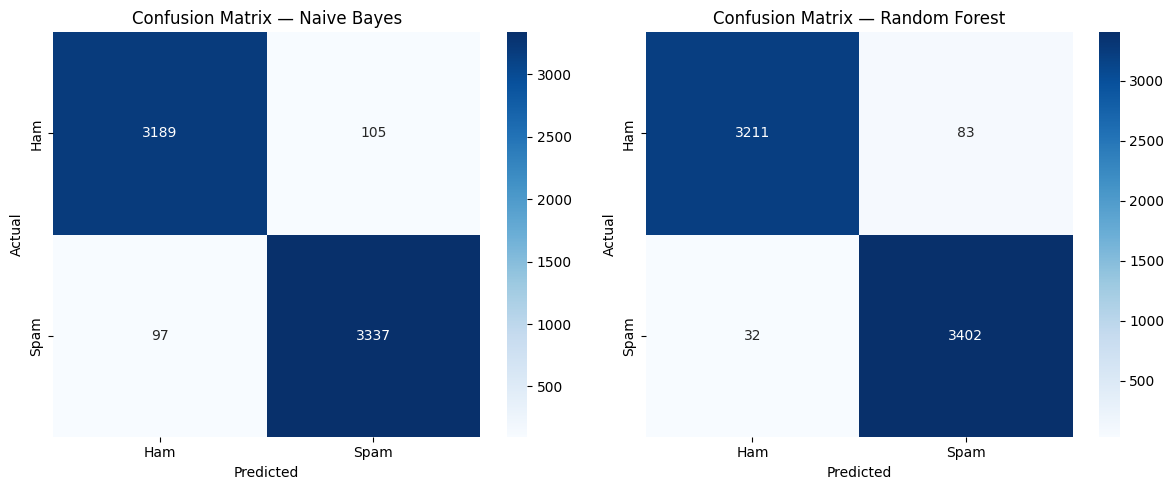

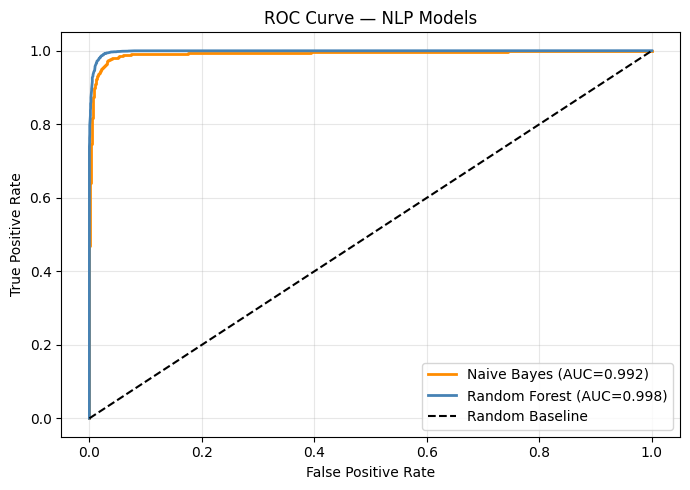

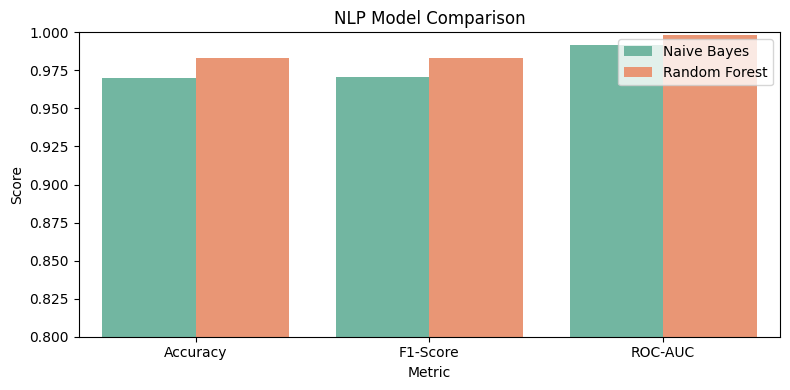

        Model  Accuracy  F1-Score  ROC-AUC
  Naive Bayes  0.969976  0.970622 0.991982
Random Forest  0.982907  0.983379 0.998387


In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred in [
    (axes[0], 'Naive Bayes',   y_pred_mnb),
    (axes[1], 'Random Forest', y_pred_rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Osas/plots/nlp_confusion_matrices.png', dpi=150)
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_proba, color in [
    ('Naive Bayes',   y_proba_mnb, 'darkorange'),
    ('Random Forest', y_proba_rf,  'steelblue')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1],'k--', label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — NLP Models')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Osas/plots/nlp_roc_curves.png', dpi=150)
plt.show()

# Bar Comparison
metrics_df = pd.DataFrame({
    'Model'    : ['Naive Bayes', 'Random Forest'],
    'Accuracy' : [accuracy_score(y_test, y_pred_mnb), accuracy_score(y_test, y_pred_rf)],
    'F1-Score' : [f1_score(y_test, y_pred_mnb),       f1_score(y_test, y_pred_rf)],
    'ROC-AUC'  : [roc_auc_score(y_test, y_proba_mnb), roc_auc_score(y_test, y_proba_rf)]
})

metrics_melt = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=metrics_melt, x='Metric', y='Score', hue='Model',
            palette='Set2', ax=ax)
ax.set_ylim(0.8, 1.0)
ax.set_title('NLP Model Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Osas/plots/nlp_model_comparison.png', dpi=150)
plt.show()

print(metrics_df.to_string(index=False))

### 2.8 Save NLP Models and Artefacts

In this last step, I save the trained models, the vectorizer, and the extra support files so the interface can reuse them without training again.

In [ ]:
# Save all NLP artefacts needed for the interface
with open('/content/drive/MyDrive/Colab Notebooks/Osas/saved_models/mnb_model.pkl', 'wb') as f:
    pickle.dump(mnb, f)

with open('/content/drive/MyDrive/Colab Notebooks/Osas/saved_models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('/content/drive/MyDrive/Colab Notebooks/Osas/saved_models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('/content/drive/MyDrive/Colab Notebooks/Osas/saved_models/chi2_selector.pkl', 'wb') as f:
    pickle.dump(chi2_selector, f)

# Save phishing keywords list for use in interface
with open('/content/drive/MyDrive/Colab Notebooks/Osas/saved_models/phishing_keywords.json', 'w') as f:
    json.dump(phishing_keywords, f)

# Save stat feature column names for interface reconstruction
with open('/content/drive/MyDrive/Colab Notebooks/Osas/saved_models/stat_feature_cols.json', 'w') as f:
    json.dump(stat_feature_cols, f)

print(' NLP models saved to saved_models/')
print('   - mnb_model.pkl')
print('   - rf_model.pkl')
print('   - tfidf_vectorizer.pkl')
print('   - chi2_selector.pkl')
print('   - phishing_keywords.json')
print('   - stat_feature_cols.json')

 NLP models saved to saved_models/
   - mnb_model.pkl
   - rf_model.pkl
   - tfidf_vectorizer.pkl
   - chi2_selector.pkl
   - phishing_keywords.json
   - stat_feature_cols.json
